# Cognifyz Technologies Internship
## Level 2 – Business Insights and Feature Engineering

### Project:
Restaurant Data Analysis using Zomato Dataset

**Prepared by:** Anirban Garai

---

### Objective

The objective of this notebook is to analyze restaurant business features such as table booking, online delivery, and price range. Additionally, feature engineering techniques are applied to create new variables that can improve future predictive modeling.

In [1]:
# ==========================
# Import Required Libraries
# ==========================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

In [3]:
# Load Dataset

df = pd.read_csv("Dataset .csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [5]:
# Display first five rows

df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [6]:
# Display last five rows

df.tail()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
9546,5915730,Naml۱ Gurme,208,��stanbul,"Kemanke�� Karamustafa Pa��a Mahallesi, R۱ht۱m ...",Karak�_y,"Karak�_y, ��stanbul",28.977392,41.022793,Turkish,80,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788
9547,5908749,Ceviz A��ac۱,208,��stanbul,"Ko��uyolu Mahallesi, Muhittin ��st�_nda�� Cadd...",Ko��uyolu,"Ko��uyolu, ��stanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",105,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034
9548,5915807,Huqqa,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.034640,41.055817,"Italian, World Cuisine",170,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,A���k Kahve,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.036019,41.057979,Restaurant Cafe,120,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901
9550,5927402,Walter's Coffee Roastery,208,��stanbul,"Cafea��a Mahallesi, Bademalt۱ Sokak, No 21/B, ...",Moda,"Moda, ��stanbul",29.026016,40.984776,Cafe,55,Turkish Lira(TL),No,No,No,No,2,4.0,Green,Very Good,591


---

---

# Task 1
## Table Booking and Online Delivery

### Objectives

- Determine the percentage of restaurants offering table booking.
- Determine the percentage of restaurants offering online delivery.
- Compare average ratings based on table booking.
- Analyze online delivery across different price ranges.

In [7]:
# Percentage of Table Booking

table_booking = df["Has Table booking"].value_counts()

table_booking_percent = round(
    (table_booking/len(df))*100,
    2
)

table_booking_percent

,count
Has Table booking,
No,87.88
Yes,12.12


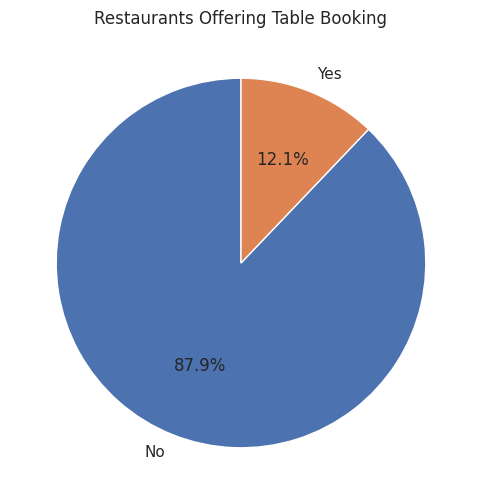

In [8]:
plt.figure(figsize=(6,6))

plt.pie(
    table_booking,
    labels=table_booking.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Restaurants Offering Table Booking")

plt.show()

In [9]:
# Percentage of Online Delivery

online_delivery = df["Has Online delivery"].value_counts()

online_delivery_percent = round(
    (online_delivery/len(df))*100,
    2
)

online_delivery_percent

,count
Has Online delivery,
No,74.34
Yes,25.66


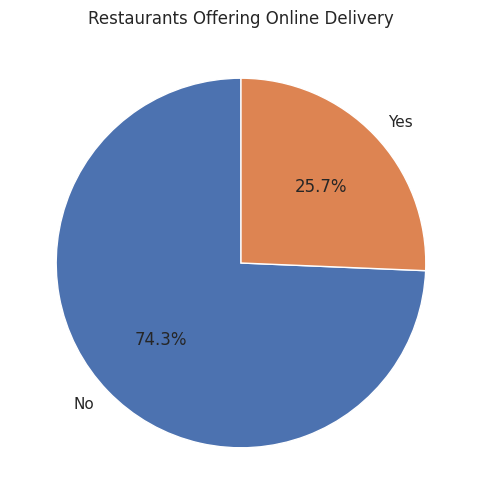

In [10]:
plt.figure(figsize=(6,6))

plt.pie(
    online_delivery,
    labels=online_delivery.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Restaurants Offering Online Delivery")

plt.show()

In [11]:
# Compare Average Ratings

rating_booking = df.groupby(
    "Has Table booking"
)["Aggregate rating"].mean()

rating_booking

,Aggregate rating
Has Table booking,
No,2.559359
Yes,3.441969


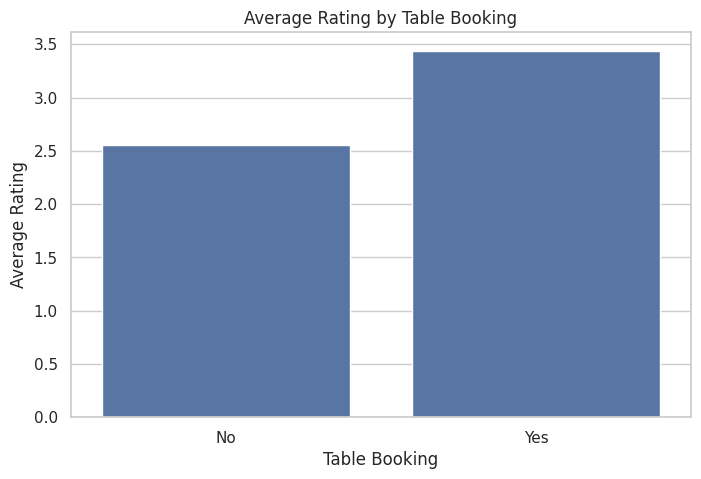

In [12]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=rating_booking.index,
    y=rating_booking.values
)

plt.title("Average Rating by Table Booking")

plt.xlabel("Table Booking")

plt.ylabel("Average Rating")

plt.show()

In [16]:
# Online Delivery by Price Range

delivery_price = pd.crosstab(
    df["Price range"],
    df["Has Online delivery"]
)

delivery_price

Has Online delivery,No,Yes
Price range,,
1,3743,701
2,1827,1286
3,997,411
4,533,53


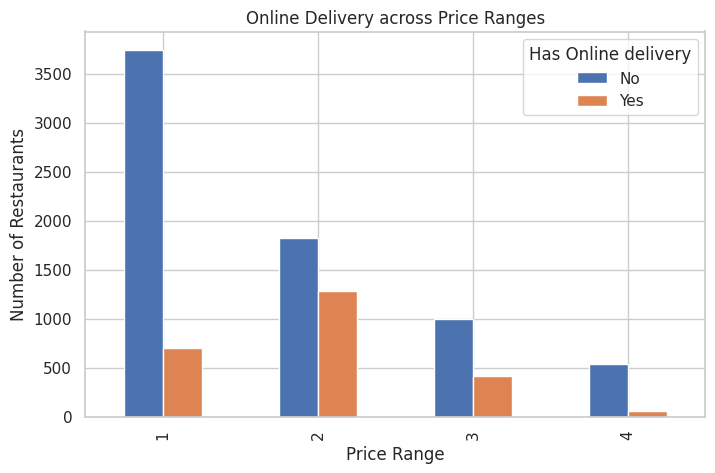

In [17]:
delivery_price.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Online Delivery across Price Ranges")

plt.xlabel("Price Range")

plt.ylabel("Number of Restaurants")

plt.show()

### Observations

- Only a small percentage of restaurants offer table booking services.
- Online delivery is available in fewer restaurants compared to those without delivery.
- Restaurants with table booking generally have higher average customer ratings.
- Online delivery is more common among restaurants in the lower and mid-price ranges than in premium restaurants.

---

---

# Task 2
## Price Range Analysis

### Objectives

- Determine the most common price range.
- Calculate average rating for each price range.
- Identify the rating color associated with the highest average rating.

In [19]:
# Most Common Price Range

price_count = df["Price range"].value_counts()

price_count

,count
Price range,
1,4444
2,3113
3,1408
4,586


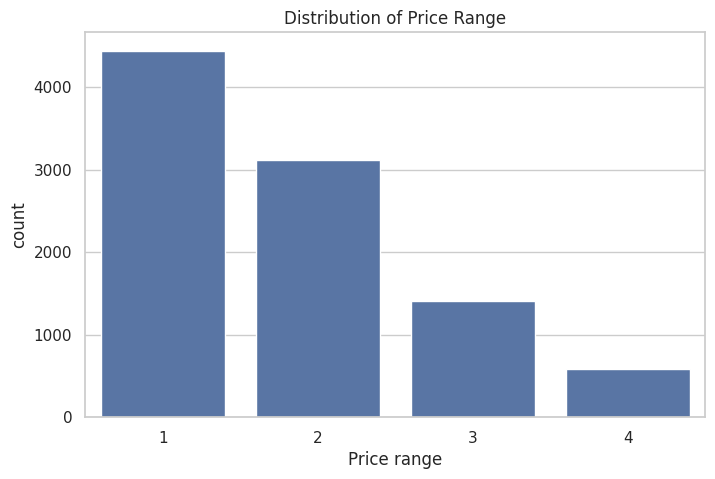

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Price range",
    data=df
)

plt.title("Distribution of Price Range")

plt.show()

In [22]:
# Average Rating by Price Range

price_rating = df.groupby(
    "Price range"
)["Aggregate rating"].mean()

price_rating

,Aggregate rating
Price range,
1,1.999887
2,2.941054
3,3.683381
4,3.817918


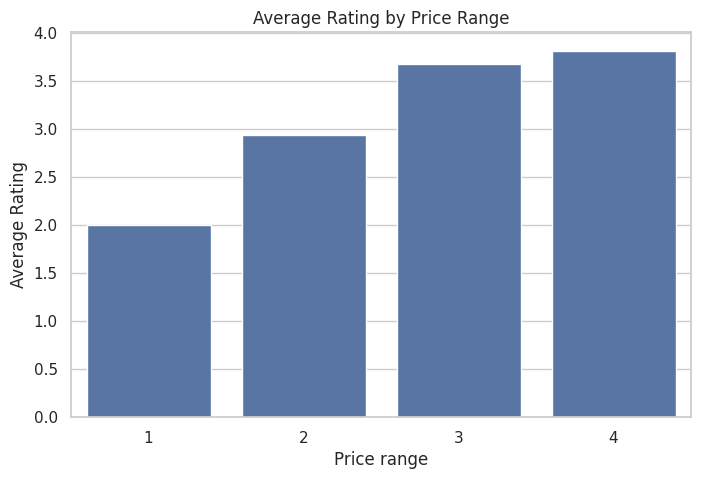

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=price_rating.index,
    y=price_rating.values
)

plt.title("Average Rating by Price Range")

plt.ylabel("Average Rating")

plt.show()

In [24]:
# Rating Color Analysis

rating_color = df.groupby(
    "Rating color"
)["Aggregate rating"].mean().sort_values(
    ascending=False
)

rating_color

,Aggregate rating
Rating color,
Dark Green,4.659801
Green,4.168119
Yellow,3.683429
Orange,3.051619
Red,2.297849
White,0.000000


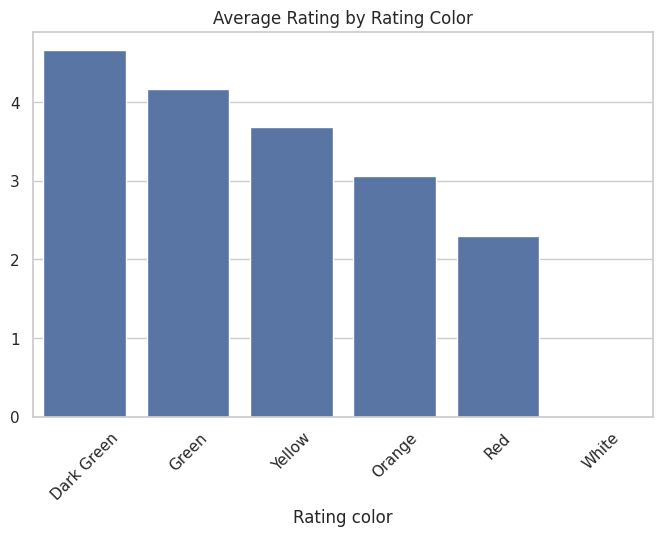

In [25]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=rating_color.index,
    y=rating_color.values
)

plt.title("Average Rating by Rating Color")

plt.xticks(rotation=45)

plt.show()

In [26]:
# Highest Rated Color

print("Highest Rated Color:")

print(rating_color.idxmax())

Highest Rated Color:
Dark Green


### Observations

- The majority of restaurants fall within the lower and mid-price ranges.
- Higher price ranges generally receive better average customer ratings.
- Restaurants represented by the **Dark Green** rating color have the highest average aggregate rating.
- Price range appears to have a positive relationship with restaurant ratings, although other factors may also influence customer satisfaction.

---

---

# Task 3
## Feature Engineering

### Objectives

- Extract new features from existing columns.
- Encode categorical variables for future machine learning models.

In [27]:
# Restaurant Name Length

df["Restaurant Name Length"] = df["Restaurant Name"].str.len()

In [28]:
# Address Length

df["Address Length"] = df["Address"].str.len()

In [30]:
# Encode Table Booking

df["Has Table Booking"] = df[
    "Has Table booking"
].map({
    "Yes":1,
    "No":0
})

In [32]:
# Encode Online Delivery

df["Has Online Delivery"] = df[
    "Has Online delivery"
].map({
    "Yes":1,
    "No":0
})

In [33]:
# Display New Features

df[[
    "Restaurant Name",
    "Restaurant Name Length",
    "Address",
    "Address Length",
    "Has Table booking",
    "Has Table Booking",
    "Has Online delivery",
    "Has Online Delivery"
]].head()

,Restaurant Name,Restaurant Name Length,Address,Address Length,Has Table booking,Has Table Booking,Has Online delivery,Has Online Delivery
0,Le Petit Souffle,16,"Third Floor, Century City Mall, Kalayaan Avenu...",71,Yes,1,No,0
1,Izakaya Kikufuji,16,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...",67,Yes,1,No,0
2,Heat - Edsa Shangri-La,22,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...",56,Yes,1,No,0
3,Ooma,4,"Third Floor, Mega Fashion Hall, SM Megamall, O...",70,No,0,No,0
4,Sambo Kojin,11,"Third Floor, Mega Atrium, SM Megamall, Ortigas...",64,Yes,1,No,0


In [34]:
# Summary Statistics of New Features

df[[
    "Restaurant Name Length",
    "Address Length",
    "Has Table Booking",
    "Has Online Delivery"
]].describe()

,Restaurant Name Length,Address Length,Has Table Booking,Has Online Delivery
count,9551.000000,9551.000000,9551.000000,9551.000000
mean,15.164171,53.536698,0.121244,0.256622
std,6.858392,17.122035,0.326428,0.436792
min,2.000000,13.000000,0.000000,0.000000
25%,10.000000,41.000000,0.000000,0.000000
50%,14.000000,52.000000,0.000000,0.000000
75%,19.000000,64.000000,0.000000,1.000000
max,54.000000,132.000000,1.000000,1.000000


### Observations

- New numerical features were successfully extracted from text columns.
- Restaurant and address lengths may capture useful information about naming and location characteristics.
- Table booking and online delivery were converted into binary numerical variables.
- These engineered features can improve the performance of predictive models in future analyses.

---

# Level 2 Conclusion

This level focused on analyzing key business features of restaurants, including table booking availability, online delivery services, and pricing strategies. The analysis showed how these features relate to customer ratings and restaurant operations. Feature engineering techniques were also applied to create additional numerical variables and encode categorical data, making the dataset more suitable for predictive modeling in the next level. Overall, the insights gained from this analysis provide a better understanding of restaurant business patterns and prepare the dataset for machine learning applications.